In [1]:
import numpy as numpy 
import pandas as pd

In [2]:
df1=pd.read_csv('cleaned_hamrobazaar_land_v3.csv')
temp_df1=df1.copy()

In [3]:
df2=pd.read_csv("cleaned_nepali_land_v3.csv")
temp_df2=df2.copy()

In [4]:
print("=== df1 (HB Land) ===")
print(f"Shape: {df1.shape}")
print(f"Columns: {list(df1.columns)}")

print("\n=== df2 (Nepali Land) ===")
print(f"Shape: {df2.shape}")
print(f"Columns: {list(df2.columns)}")

print("\n=== df1 Nulls ===")
print(df1.isnull().sum()[df1.isnull().sum() > 0])

print("\n=== df2 Nulls ===")
print(df2.isnull().sum()[df2.isnull().sum() > 0])

=== df1 (HB Land) ===
Shape: (3584, 15)
Columns: ['category', 'ad_id', 'title', 'location_raw', 'district', 'neighborhood', 'road_type', 'raw_price', 'land_size_aana', 'price_per_aana', 'calculated_total_price', 'is_price_suspect', 'is_price_outlier', 'is_rate_outlier', 'is_large_plot']

=== df2 (Nepali Land) ===
Shape: (2043, 15)
Columns: ['category', 'neighborhood', 'district', 'location_raw', 'price_per_aana', 'land_size_aana', 'calculated_total_price', 'road_width_feet', 'road_type', 'facing', 'is_wide_road', 'is_price_suspect', 'is_large_plot', 'is_rate_outlier', 'is_price_outlier']

=== df1 Nulls ===
Series([], dtype: int64)

=== df2 Nulls ===
price_per_aana             152
land_size_aana            1282
calculated_total_price    1263
road_width_feet             96
road_type                   75
facing                      42
dtype: int64


## df2 has 63% missing land_size_aana — this is a critical column for land pricing. Before doing EDA we need to decide: ##

In [5]:
# Check how many rows have BOTH price_per_aana AND land_size_aana present
complete = df2[df2['land_size_aana'].notna() & df2['price_per_aana'].notna()]
print(f"Complete rows: {len(complete)} out of {len(df2)}")
print(f"Missing land_size_aana but has price_per_aana: {df2['land_size_aana'].isna().sum()}")

Complete rows: 728 out of 2043
Missing land_size_aana but has price_per_aana: 1282


In [6]:
# Check common columns
df1_cols = set(df1.columns)
df2_cols = set(df2.columns)

print("Common columns:")
print(df1_cols.intersection(df2_cols))

print("\nOnly in df1:")
print(df1_cols - df2_cols)

print("\nOnly in df2:")
print(df2_cols - df1_cols)

# Check district overlap
print("\ndf1 districts:", df1['district'].unique())
print("df2 districts:", df2['district'].unique())

# Check price_per_aana range compatibility
print("\ndf1 price_per_aana stats:")
print(df1['price_per_aana'].describe())
print("\ndf2 price_per_aana stats:")
print(df2[df2['price_per_aana'].notna()]['price_per_aana'].describe())

Common columns:
{'is_price_suspect', 'location_raw', 'category', 'price_per_aana', 'calculated_total_price', 'road_type', 'is_rate_outlier', 'neighborhood', 'district', 'land_size_aana', 'is_price_outlier', 'is_large_plot'}

Only in df1:
{'title', 'raw_price', 'ad_id'}

Only in df2:
{'is_wide_road', 'facing', 'road_width_feet'}

df1 districts: ['Kathmandu' 'Bhaktapur' 'Lalitpur']
df2 districts: ['Bhaktapur' 'Lalitpur' 'Kathmandu' 'Rupandehi' 'Chitwan' 'Dhanusa'
 'Nuwakot' 'Jhapa' 'Dhading' 'Kaski' 'Morang' 'Ilam' 'Tanahun'
 'Kavrepalanchok' 'Kailali' 'Rautahat' 'Makwanpur' 'Sunsari' 'Udayapur'
 'Palpa' 'Nawalpur']

df1 price_per_aana stats:
count    3.584000e+03
mean     5.287719e+06
std      3.218019e+06
min      6.000000e+04
25%      3.050000e+06
50%      4.500000e+06
75%      6.500000e+06
max      2.000000e+07
Name: price_per_aana, dtype: float64

df2 price_per_aana stats:
count    1.891000e+03
mean     4.691826e+06
std      5.050529e+06
min      7.711443e+03
25%      3.200000e+06
5

In [7]:
valley = ['Kathmandu', 'Lalitpur', 'Bhaktapur']
df2_valley = df2[df2['district'].isin(valley) & df2['land_size_aana'].notna()].copy()
print(f"df2 valley complete rows: {len(df2_valley)}")

df2 valley complete rows: 707


In [8]:
# ─────────────────────────────────────────
# STEP 1 — PREPARE df1
# ─────────────────────────────────────────
df1_clean = df1.copy()

# Add missing columns that df2 has
df1_clean['road_width_feet'] = None
df1_clean['is_wide_road']    = False
df1_clean['facing']          = None
df1_clean['source']          = 'hamrobazaar'

# Drop df1 only columns
df1_clean.drop(columns=['ad_id', 'title', 'raw_price'], inplace=True)

# ─────────────────────────────────────────
# STEP 2 — PREPARE df2
# ─────────────────────────────────────────
# Filter to valley only and complete rows
valley    = ['Kathmandu', 'Lalitpur', 'Bhaktapur']
df2_clean = df2[
    df2['district'].isin(valley) &
    df2['land_size_aana'].notna() &
    df2['price_per_aana'].notna()
].copy()

df2_clean['source'] = 'nepali_land'

# ─────────────────────────────────────────
# STEP 3 — MERGE
# ─────────────────────────────────────────
df_land = pd.concat([df1_clean, df2_clean], ignore_index=True)

print(f"df1 rows:       {len(df1_clean)}")
print(f"df2 rows:       {len(df2_clean)}")
print(f"Combined rows:  {len(df_land)}")
print(f"Columns:        {list(df_land.columns)}")

print("\n=== Nulls after merge ===")
nulls = df_land.isnull().sum()
print(nulls[nulls > 0])

print("\n=== price_per_aana stats ===")
print(df_land['price_per_aana'].describe())

df1 rows:       3584
df2 rows:       680
Combined rows:  4264
Columns:        ['category', 'location_raw', 'district', 'neighborhood', 'road_type', 'land_size_aana', 'price_per_aana', 'calculated_total_price', 'is_price_suspect', 'is_price_outlier', 'is_rate_outlier', 'is_large_plot', 'road_width_feet', 'is_wide_road', 'facing', 'source']

=== Nulls after merge ===
road_type            20
road_width_feet    3606
facing             3596
dtype: int64

=== price_per_aana stats ===
count    4.264000e+03
mean     5.221264e+06
std      4.188424e+06
min      6.000000e+04
25%      3.100000e+06
50%      4.500000e+06
75%      6.500000e+06
max      1.749000e+08
Name: price_per_aana, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\1261512449.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_land = pd.concat([df1_clean, df2_clean], ignore_index=True)


In [9]:
# Fill small nulls
df_land['road_type'] = df_land['road_type'].fillna('Unknown')
df_land['facing']    = df_land['facing'].fillna('Unknown')

# road_width_feet — fill with median of df2 only (df1 never had it)
df2_median_road = df2_clean['road_width_feet'].median()
df_land['road_width_feet'] = df_land['road_width_feet'].fillna(df2_median_road)

# Verify
print("=== Nulls after fix ===")
nulls = df_land.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].any() else "✅ No nulls")

print(f"\nFinal shape: {df_land.shape}")

=== Nulls after fix ===
✅ No nulls

Final shape: (4264, 16)


In [10]:
df_land.sample(12)

,category,location_raw,district,neighborhood,road_type,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot,road_width_feet,is_wide_road,facing,source
4033,land,"Naya Thimi, Bhaktapur",Bhaktapur,Naya Thimi,Pitched,7.3,4000000.0,29200000.0,False,False,False,False,20.0,False,East,nepali_land
160,land,"Kathmandu Metropolitan City, Kathmandu",Kathmandu,Kathmandu Metropolitan,13-20 Ft,10.0,6500000.0,65000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
469,land,"Jadibuti Petrol Pump, Kathmandu-32, Kathmandu",Kathmandu,Jadibuti Petrol Pump,Pitched Road,5.0,6000000.0,30000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
1848,land,"Budhanilkantha, Budhanilkantha Municipality, K...",Kathmandu,Budhanilkantha,Above 20 Ft,8.0,4500000.0,36000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
1548,land,"Naikap, Tribhuvan Rajpath, Chandragiri-14, Kat...",Kathmandu,Naikap,Pitched Road,3.0,3600000.0,10800000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
2494,land,"बाबा चोक, Kageshwori Manohara-06, कागेश्वरी मन...",Kathmandu,बाबा चोक,Pitched Road,5.0,3500000.0,17500000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
3170,land,"Tripureshwor, Kathmandu",Kathmandu,Tripureshwor,Unknown,8.0,17000000.0,136000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
2799,land,"धरमपुर, Budhanilkantha-07, बूढानीलकण्ठ, बूढानि...",Kathmandu,धरमपुर,13-20 Ft,6.0,5700000.0,34200000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
3487,land,"Sunakothi, Lalitpur",Lalitpur,Sunakothi,Unknown,49.0,2200000.0,107800000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
1017,land,"Kirtipur, Ajaya Marga, Kirtipur-6, Kathmandu",Kathmandu,Kirtipur,Pitched Road,3.0,3200000.0,9600000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar


C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\1917862516.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='district', y='price_per_aana', ax=axes[1,1], palette='Set2')


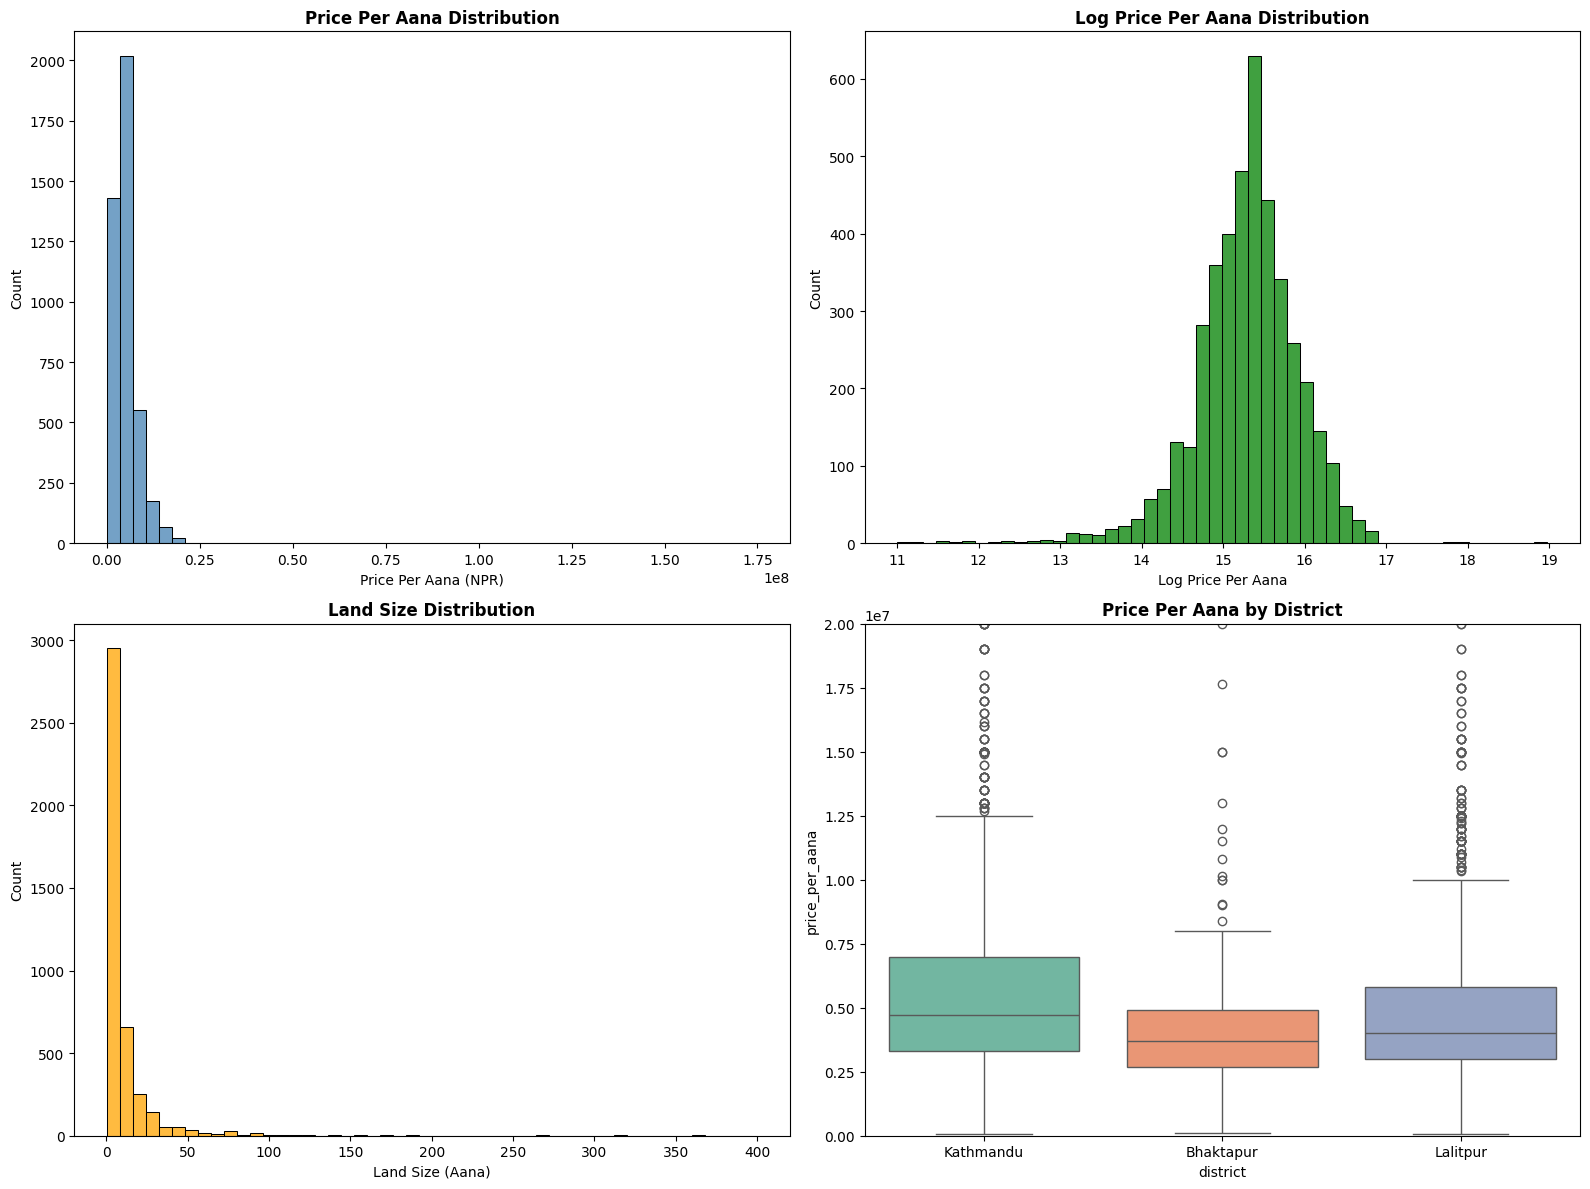

=== price_per_aana by district ===
district
Kathmandu    4700000.0
Lalitpur     4000000.0
Bhaktapur    3700000.0
Name: price_per_aana, dtype: float64

=== Source distribution ===
source
hamrobazaar    3584
nepali_land     680
Name: count, dtype: int64

=== Road type distribution ===
road_type
Pitched Road    800
13-20 Ft        785
Unknown         768
Above 20 Ft     754
Gravel Road     320
Gravel          263
Paved           228
Pitched         169
9-12 Ft         104
Full Road        73
Name: count, dtype: int64

=== land_size_aana stats ===
count    4264.000000
mean       12.068982
std        24.094603
min         0.400000
25%         4.000000
50%         5.300000
75%        10.373151
max       400.000000
Name: land_size_aana, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np    

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — price_per_aana distribution
sns.histplot(df_land['price_per_aana'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Per Aana Distribution', fontweight='bold')
axes[0,0].set_xlabel('Price Per Aana (NPR)')

# Plot 2 — log price distribution
sns.histplot(np.log1p(df_land['price_per_aana']), bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Log Price Per Aana Distribution', fontweight='bold')
axes[0,1].set_xlabel('Log Price Per Aana')

# Plot 3 — land_size_aana distribution
sns.histplot(df_land['land_size_aana'], bins=50, ax=axes[1,0], color='orange')
axes[1,0].set_title('Land Size Distribution', fontweight='bold')
axes[1,0].set_xlabel('Land Size (Aana)')

# Plot 4 — price_per_aana by district
sns.boxplot(data=df_land, x='district', y='price_per_aana', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Price Per Aana by District', fontweight='bold')
axes[1,1].set_ylim(0, 20000000)

plt.tight_layout()
plt.show()

# Basic stats
print("=== price_per_aana by district ===")
print(df_land.groupby('district')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Source distribution ===")
print(df_land['source'].value_counts())

print("\n=== Road type distribution ===")
print(df_land['road_type'].value_counts())

print("\n=== land_size_aana stats ===")
print(df_land['land_size_aana'].describe())

In [12]:
# Standardize road type values
road_map = {
    'Pitched Road': 'Pitched',
    'Gravel Road':  'Gravel',
    'Paved':        'Paved',
    'Above 20 Ft':  'Wide Road',
    '13-20 Ft':     'Medium Road',
    '9-12 Ft':      'Narrow Road',
    'Full Road':    'Wide Road',
    'Alley':        'Narrow Road',
    'Unknown':      'Unknown'
}
df_land['road_type'] = df_land['road_type'].replace(road_map)

print("=== Road type after standardization ===")
print(df_land['road_type'].value_counts())

=== Road type after standardization ===
road_type
Pitched        969
Wide Road      827
Medium Road    785
Unknown        768
Gravel         583
Paved          228
Narrow Road    104
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\2856013484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='road_type', y='price_per_aana',
C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\2856013484.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='source', y='price_per_aana',


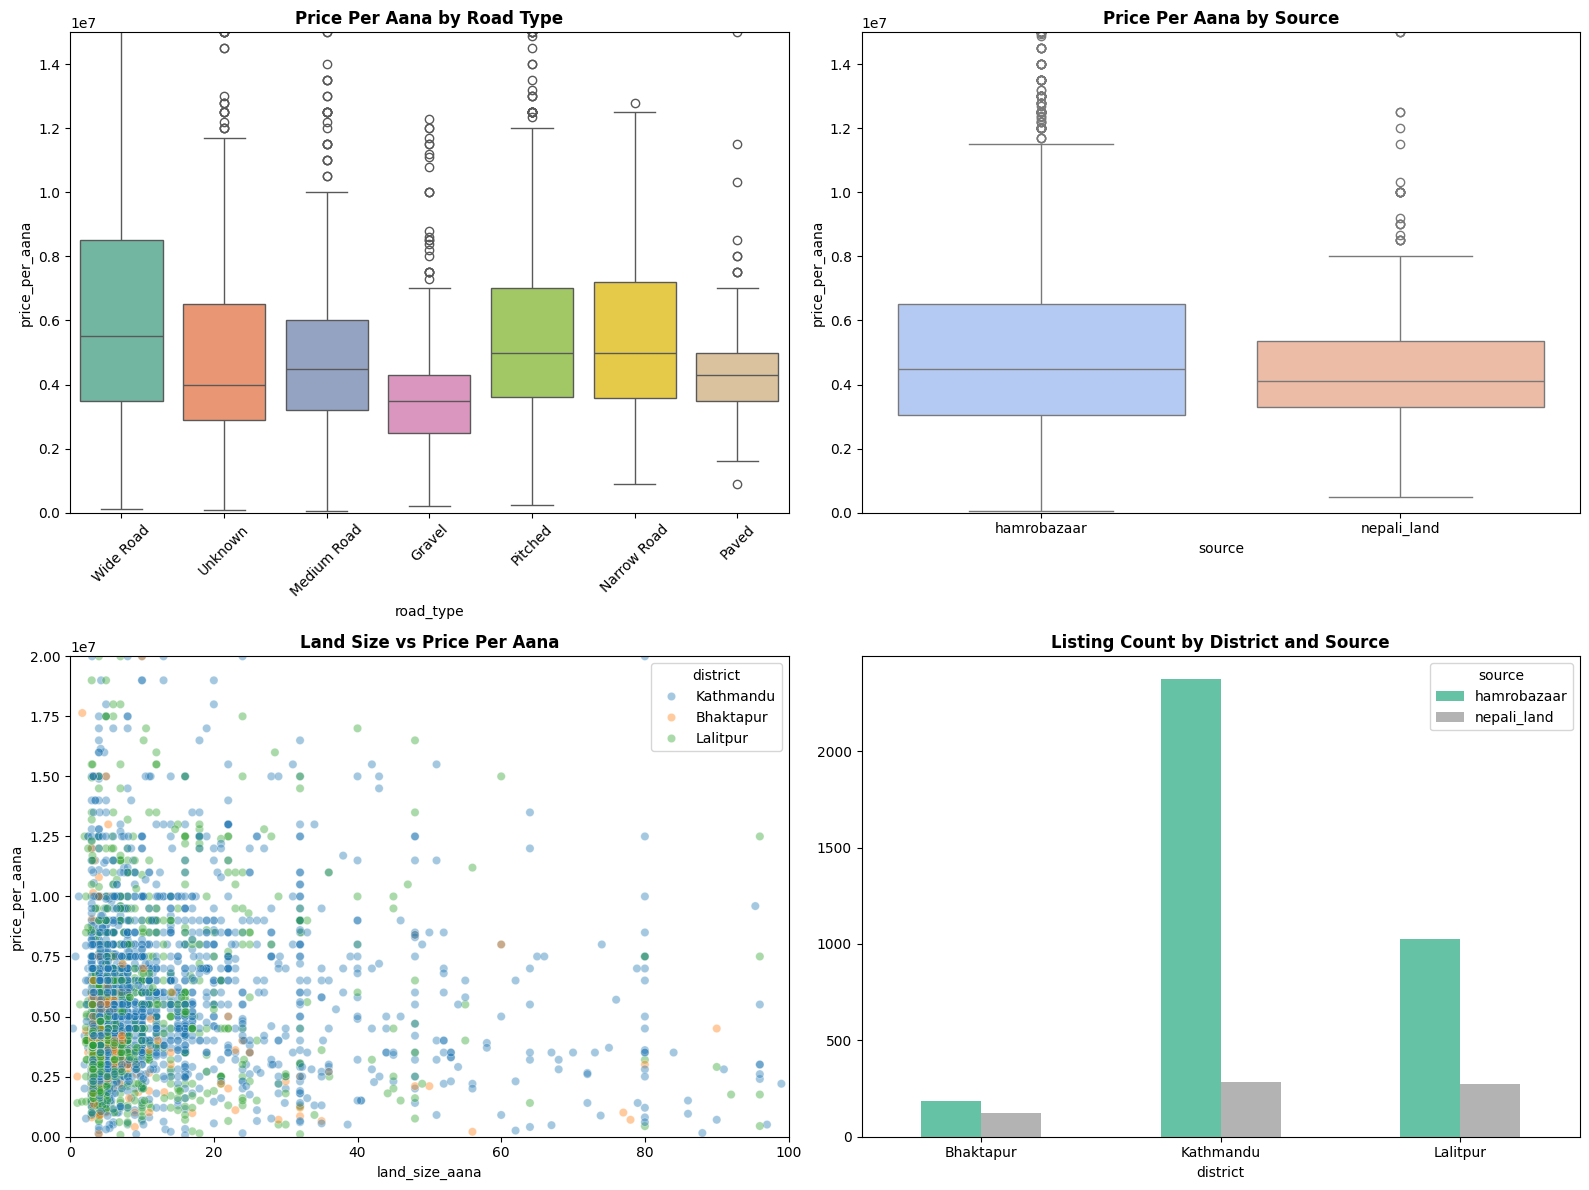

=== Price by road type ===
road_type
Wide Road      5500000.0
Pitched        5000000.0
Narrow Road    5000000.0
Medium Road    4500000.0
Paved          4300000.0
Unknown        4000000.0
Gravel         3500000.0
Name: price_per_aana, dtype: float64

=== Price by source ===
source
hamrobazaar    4500000.0
nepali_land    4100000.0
Name: price_per_aana, dtype: float64

=== Correlation with price_per_aana ===
price_per_aana     1.000000
land_size_aana    -0.011087
road_width_feet    0.023344
Name: price_per_aana, dtype: float64


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — price_per_aana by road type
sns.boxplot(data=df_land, x='road_type', y='price_per_aana', 
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price Per Aana by Road Type', fontweight='bold')
axes[0,0].set_ylim(0, 15000000)
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 — price_per_aana by source
sns.boxplot(data=df_land, x='source', y='price_per_aana',
            ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Price Per Aana by Source', fontweight='bold')
axes[0,1].set_ylim(0, 15000000)

# Plot 3 — land size vs price scatter
sns.scatterplot(data=df_land, x='land_size_aana', y='price_per_aana',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('Land Size vs Price Per Aana', fontweight='bold')
axes[1,0].set_xlim(0, 100)
axes[1,0].set_ylim(0, 20000000)

# Plot 4 — listing count by district and source
df_land.groupby(['district','source']).size().unstack().plot(
    kind='bar', ax=axes[1,1], colormap='Set2')
axes[1,1].set_title('Listing Count by District and Source', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Stats
print("=== Price by road type ===")
print(df_land.groupby('road_type')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Price by source ===")
print(df_land.groupby('source')['price_per_aana'].median())

print("\n=== Correlation with price_per_aana ===")
print(df_land[['price_per_aana','land_size_aana','road_width_feet']].corr()['price_per_aana'])

## =============================================================================
# 📊 LAND DATASET EDA — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# 1. PRICE PER AANA BY ROAD TYPE (Top Left)
# -----------------------------------------------------------------------------
# - Wide Road:   Highest median price per aana (~5.5M NPR) — commands clear premium
# - Unknown:     Surprisingly high median (~4.2M) — likely urban plots with unclear road info
# - Medium Road: Median ~4.8M — close to wide road (good access still valued)
# - Gravel:      Lowest median (~3.5M) — unpaved roads significantly reduce land value
# - Pitched:     Median ~5M — paved roads command similar price to wide roads
# - Narrow Road: Median ~5M but wider spread — location compensates for narrow access
# - Paved:       Similar to narrow road (~4M)
# → Road type is a meaningful price differentiator — Wide and Pitched roads
#   command the highest per-aana prices
# → Gravel road properties are the most affordable land category

# -----------------------------------------------------------------------------
# 2. PRICE PER AANA BY SOURCE (Top Right)
# -----------------------------------------------------------------------------
# - Hamrobazaar: Median ~4.7M per aana, wider spread, more high-end outliers
# - Nepali Land: Median ~4.2M per aana, slightly lower, fewer extreme outliers
# - Both sources have very similar price distributions overall
# - Hamrobazaar has more luxury outliers (above 1.2 Crore per aana)
# → No significant bias between the two data sources — safe to merge them
# → Both sources represent the same market, just slightly different listing pools

# -----------------------------------------------------------------------------
# 3. LAND SIZE vs PRICE PER AANA (Bottom Left)
# -----------------------------------------------------------------------------
# - No clear correlation — price per aana does NOT increase with land size
# - Highest per-aana prices are actually on SMALL plots (0–10 aana)
# - As land size increases beyond 20 aana, price per aana drops and stabilizes
# - Kathmandu (blue) dominates high per-aana prices at small plot sizes
# - Bhaktapur (orange) and Lalitpur (green) cluster at lower per-aana values
# → Small plots in prime locations (Kathmandu) command the highest per-aana price
# → Larger plots are cheaper per aana — bulk land discount effect
# → Location (district) matters more than size for per-aana pricing

# -----------------------------------------------------------------------------
# 4. LISTING COUNT BY DISTRICT AND SOURCE (Bottom Right)
# -----------------------------------------------------------------------------
# - Kathmandu dominates overwhelmingly: ~2,300 hamrobazaar + ~280 nepali_land
# - Lalitpur: ~1,000 hamrobazaar + ~250 nepali_land
# - Bhaktapur: smallest — ~150 hamrobazaar + ~100 nepali_land
# - Hamrobazaar contributes far more listings than nepali_land in all districts
# → Dataset is heavily Kathmandu-centric — model will be most accurate there
# → Bhaktapur has very few listings — predictions there will be less reliable

# =============================================================================
# 🔑 OVERALL TAKEAWAYS
# =============================================================================
# 1. ROAD TYPE matters — Wide/Pitched roads command highest per-aana price
# 2. BOTH SOURCES are compatible — similar price ranges, safe to merge
# 3. SMALL PLOTS cost MORE per aana — premium for compact city-center land
# 4. KATHMANDU dominates both listing count and high per-aana prices
# 5. BHAKTAPUR is underrepresented — model predictions there need caution
# =============================================================================

In [14]:
# ─────────────────────────────────────────
# MERGED LAND DATA — CLEANING CHECK
# ─────────────────────────────────────────

print("=== Basic Info ===")
print(f"Shape: {df_land.shape}")
print(f"Nulls: {df_land.isnull().sum().sum()}")

print("\n=== price_per_aana suspicious values ===")
print(f"Zero or negative: {(df_land['price_per_aana'] <= 0).sum()}")
print(f"Below 100k:       {(df_land['price_per_aana'] < 100000).sum()}")
print(f"Above 20M:        {(df_land['price_per_aana'] > 20000000).sum()}")
print(f"Above 50M:        {(df_land['price_per_aana'] > 50000000).sum()}")

print("\n=== land_size_aana suspicious values ===")
print(f"Zero or negative: {(df_land['land_size_aana'] <= 0).sum()}")
print(f"Above 100 aana:   {(df_land['land_size_aana'] > 100).sum()}")
print(f"Above 50 aana:    {(df_land['land_size_aana'] > 50).sum()}")

print("\n=== Flag columns check ===")
print(f"is_price_suspect True:  {df_land['is_price_suspect'].sum()}")
print(f"is_price_outlier True:  {df_land['is_price_outlier'].sum()}")
print(f"is_rate_outlier True:   {df_land['is_rate_outlier'].sum()}")
print(f"is_large_plot True:     {df_land['is_large_plot'].sum()}")

print("\n=== District check ===")
print(df_land['district'].value_counts())

print("\n=== Source check ===")
print(df_land['source'].value_counts())

print("\n=== road_type check ===")
print(df_land['road_type'].value_counts())

print("\n=== Duplicate check ===")
print(f"Duplicate rows: {df_land.duplicated().sum()}")

=== Basic Info ===
Shape: (4264, 16)
Nulls: 0

=== price_per_aana suspicious values ===
Zero or negative: 0
Below 100k:       2
Above 20M:        3
Above 50M:        3

=== land_size_aana suspicious values ===
Zero or negative: 0
Above 100 aana:   36
Above 50 aana:    144

=== Flag columns check ===
is_price_suspect True:  0
is_price_outlier True:  38
is_rate_outlier True:   35
is_large_plot True:     144

=== District check ===
district
Kathmandu    2658
Lalitpur     1299
Bhaktapur     307
Name: count, dtype: int64

=== Source check ===
source
hamrobazaar    3584
nepali_land     680
Name: count, dtype: int64

=== road_type check ===
road_type
Pitched        969
Wide Road      827
Medium Road    785
Unknown        768
Gravel         583
Paved          228
Narrow Road    104
Name: count, dtype: int64

=== Duplicate check ===
Duplicate rows: 127


In [15]:
temp_df = df_land.copy()

# Step 1 — Remove duplicates
temp_df = temp_df.drop_duplicates().reset_index(drop=True)
print(f"After duplicate removal: {len(temp_df)} rows (removed {len(df_land) - len(temp_df)})")

# Step 2 — Remove suspicious price rows
before = len(temp_df)
temp_df = temp_df[
    (temp_df['price_per_aana'] >= 100000) &
    (temp_df['price_per_aana'] <= 50000000)
].reset_index(drop=True)
print(f"After price filter: {len(temp_df)} rows (removed {before - len(temp_df)})")

# Step 3 — Cap land size
temp_df['land_size_aana'] = temp_df['land_size_aana'].clip(upper=50)
print(f"land_size_aana capped at 50 aana")

# Step 4 — Drop flagged rows
before = len(temp_df)
temp_df = temp_df[
    (temp_df['is_price_outlier'] == False) &
    (temp_df['is_rate_outlier']  == False)
].reset_index(drop=True)
print(f"After flag removal: {len(temp_df)} rows (removed {before - len(temp_df)})")

# Summary
print(f"\n=== Summary ===")
print(f"Original rows:  {len(df_land)}")
print(f"Final rows:     {len(temp_df)}")
print(f"Total removed:  {len(df_land) - len(temp_df)}")
print(f"Remaining %:    {len(temp_df)/len(df_land)*100:.1f}%")

After duplicate removal: 4137 rows (removed 127)
After price filter: 4132 rows (removed 5)
land_size_aana capped at 50 aana
After flag removal: 4063 rows (removed 69)

=== Summary ===
Original rows:  4264
Final rows:     4063
Total removed:  201
Remaining %:    95.3%


In [16]:
# Commit to df_land
df_land = temp_df.copy()
print(f"✅ df_land finalized: {df_land.shape}")

✅ df_land finalized: (4063, 16)


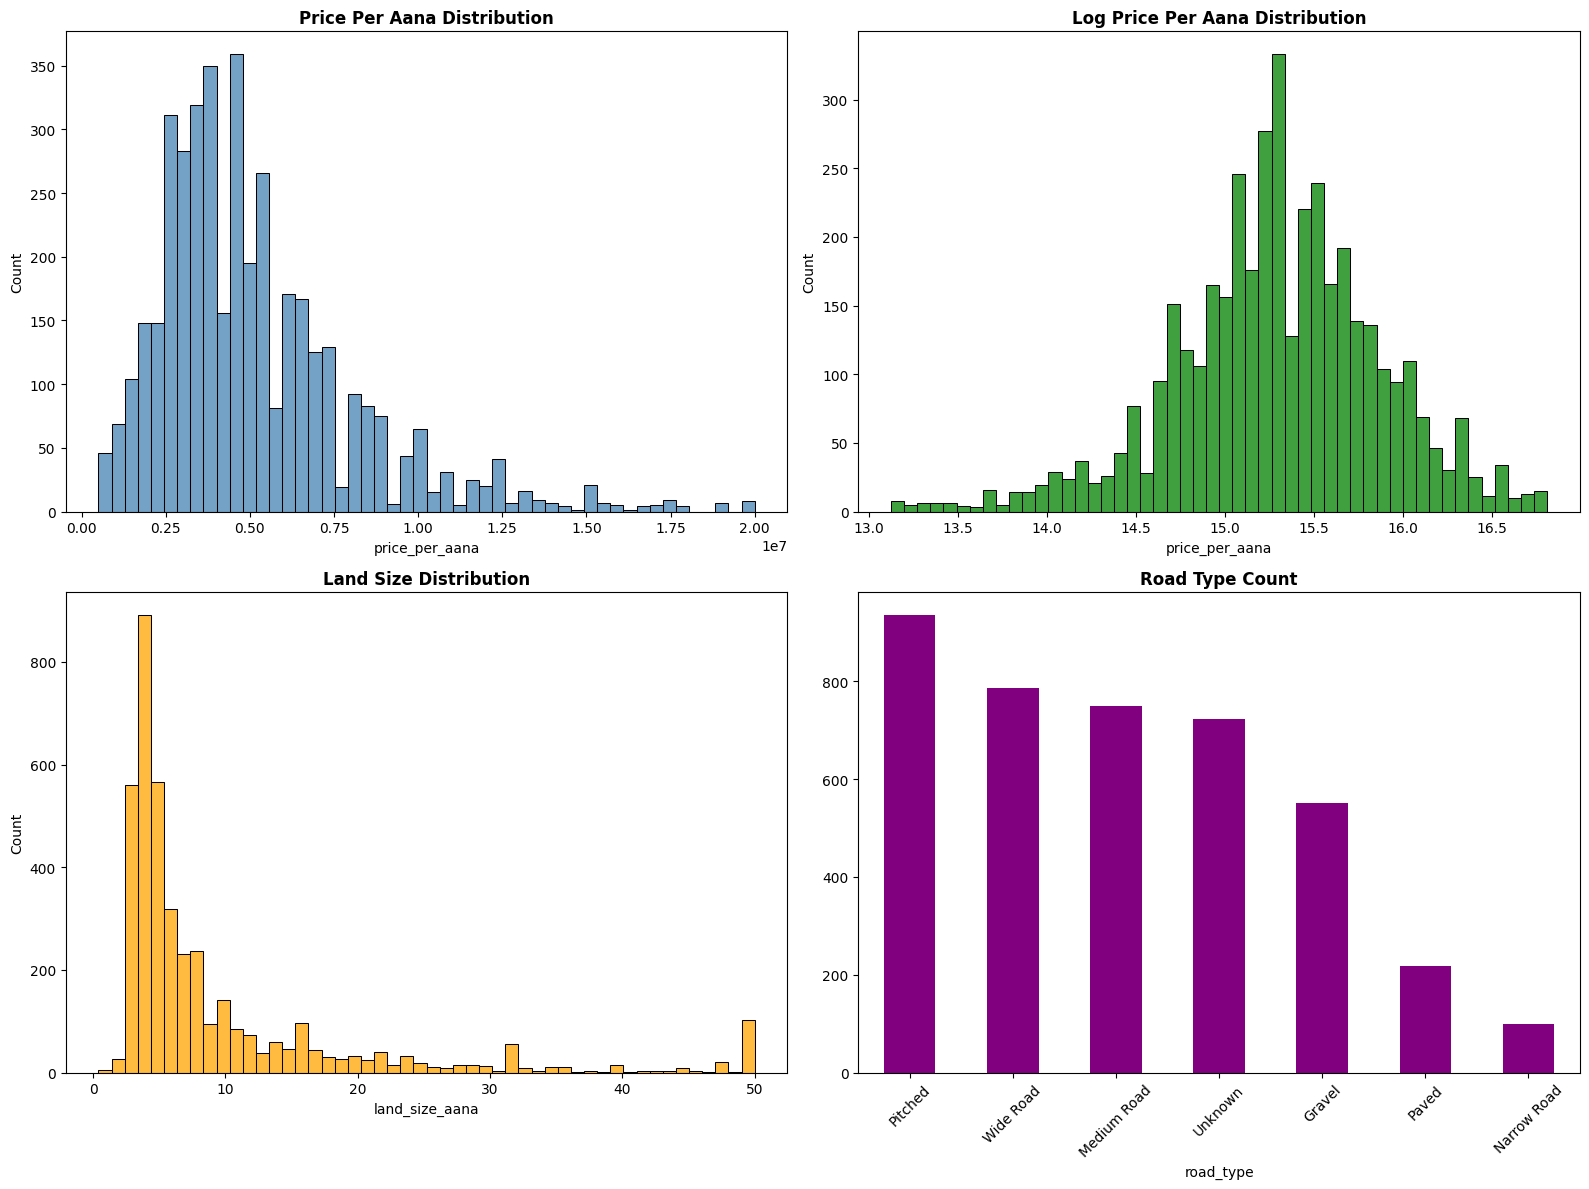

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────
# STEP 1 — UNIVARIATE ANALYSIS
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price per aana distribution
sns.histplot(df_land['price_per_aana'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Per Aana Distribution', fontweight='bold')

# Log price distribution
sns.histplot(np.log1p(df_land['price_per_aana']), bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Log Price Per Aana Distribution', fontweight='bold')

# Land size distribution
sns.histplot(df_land['land_size_aana'], bins=50, ax=axes[1,0], color='orange')
axes[1,0].set_title('Land Size Distribution', fontweight='bold')

# Road type count
df_land['road_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Road Type Count', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\3349530402.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='district', y='price_per_aana',
C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\3349530402.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='road_type', y='price_per_aana',
C:\Users\DELL\AppData\Local\Temp\ipykernel_14024\3349530402.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_land, x='source', y='price_per_aana',


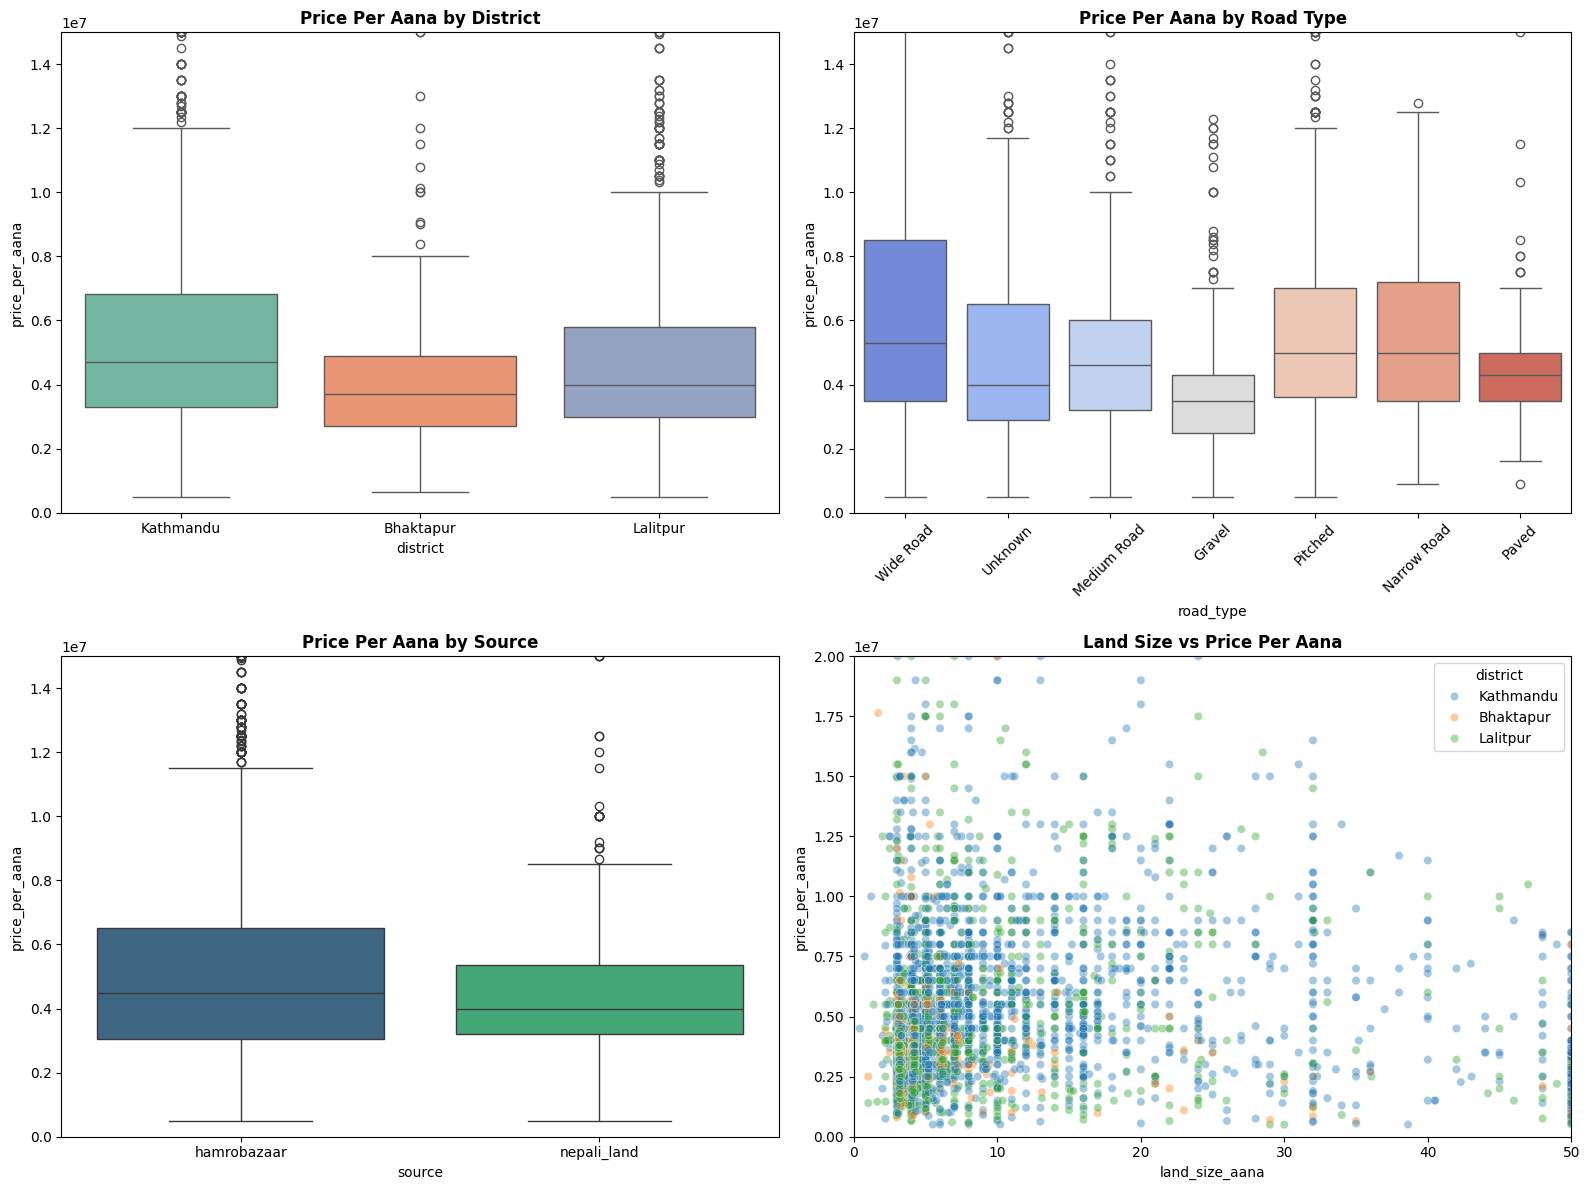

In [19]:
# ─────────────────────────────────────────
# STEP 2 — BIVARIATE ANALYSIS
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price by district
sns.boxplot(data=df_land, x='district', y='price_per_aana',
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price Per Aana by District', fontweight='bold')
axes[0,0].set_ylim(0, 15000000)

# Price by road type
sns.boxplot(data=df_land, x='road_type', y='price_per_aana',
            ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Price Per Aana by Road Type', fontweight='bold')
axes[0,1].set_ylim(0, 15000000)
axes[0,1].tick_params(axis='x', rotation=45)

# Price by source
sns.boxplot(data=df_land, x='source', y='price_per_aana',
            ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Price Per Aana by Source', fontweight='bold')
axes[1,0].set_ylim(0, 15000000)

# Land size vs price
sns.scatterplot(data=df_land, x='land_size_aana', y='price_per_aana',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Land Size vs Price Per Aana', fontweight='bold')
axes[1,1].set_xlim(0, 50)
axes[1,1].set_ylim(0, 20000000)

plt.tight_layout()
plt.show()


# =============================================================================
# 📊 LAND DATASET UNIVARIATE & BIVARIATE — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# IMAGE 1 — UNIVARIATE DISTRIBUTIONS
# -----------------------------------------------------------------------------

# PRICE PER AANA (Raw):
# - Right-skewed with peaks around 0.3M–0.5M NPR per aana
# - Long tail extending to 2 Crore per aana (luxury plots)
# → Log transformation needed before ML modeling

# LOG PRICE PER AANA:
# - After log transform, distribution becomes much more normal/bell-shaped
# - Peak around 15.0–15.5 on log scale
# → Confirms log transformation successfully normalizes the price data
# → This is the correct form to use for ML modeling

# LAND SIZE DISTRIBUTION:
# - Heavily right-skewed — majority of plots are 3–8 aana
# - Sharp peak at 3–5 aana (standard residential plot size in Nepal)
# - Long tail up to 50 aana — large/commercial plots
# - Suspicious spike at exactly 50 aana likely due to data capping
# → Most land listings are small standard residential plots

# ROAD TYPE COUNT:
# - Pitched road is most common (~920 listings)
# - Wide Road and Medium Road are close behind (~790 and ~750)
# - Gravel is least common (~550) among major categories
# - Paved is the rarest (~230)
# → Pitched road dominates — typical for Kathmandu valley residential areas

# -----------------------------------------------------------------------------
# IMAGE 2 — BIVARIATE ANALYSIS
# -----------------------------------------------------------------------------

# PRICE PER AANA BY DISTRICT:
# - Kathmandu: Highest median (~4.8M) and widest spread — most expensive district
# - Lalitpur: Median ~4.2M, moderate spread
# - Bhaktapur: Lowest median (~3.8M), tightest range — most affordable district
# - All 3 have significant outliers above 1 Crore per aana
# → District is a meaningful price differentiator for land
# → Kathmandu commands a clear location premium over Bhaktapur

# PRICE PER AANA BY ROAD TYPE:
# - Wide Road: Highest median (~5.2M) — confirms road access drives land value
# - Unknown: Second highest — likely urban plots with unrecorded road info
# - Gravel: Lowest median (~3.5M) — unpaved access significantly lowers value
# - Pitched, Narrow, Paved: Similar medians (~4.5–5M)
# → Wide road access is the most valuable road feature for land pricing

# PRICE PER AANA BY SOURCE:
# - Hamrobazaar: Slightly higher median (~4.8M), wider spread, more outliers
# - Nepali Land: Slightly lower median (~4.2M), tighter distribution
# - Both sources are largely compatible — no major systematic difference
# → Merging both sources is valid — they represent the same market

# LAND SIZE vs PRICE PER AANA (Scatter):
# - No strong correlation — land size does NOT determine price per aana
# - Highest per-aana prices cluster at SMALL plot sizes (0–10 aana)
# - Price per aana drops and spreads as land size increases
# - Kathmandu (blue) consistently sits at higher per-aana values
# - Bhaktapur (orange) and Lalitpur (green) cluster at lower values
# → Location drives per-aana price, not plot size
# → Larger plots are cheaper per aana (bulk discount effect)

# =============================================================================
# 🔑 OVERALL TAKEAWAYS
# =============================================================================
# 1. LOG TRANSFORM confirmed effective — use log(price_per_aana) for ML
# 2. KATHMANDU commands highest per-aana price across all road types
# 3. WIDE ROAD access is the most valuable road feature for land value
# 4. SMALL PLOTS (3–8 aana) dominate the market — standard residential size
# 5. BOTH DATA SOURCES are compatible — safe to merge for modeling
# 6. LAND SIZE alone cannot predict price — location is the dominant factor
# =============================================================================

In [20]:
# ─────────────────────────────────────────
# STEP 3 — KEY STATS
# ─────────────────────────────────────────
print("=== Price Per Aana by District ===")
print(df_land.groupby('district')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Price Per Aana by Road Type ===")
print(df_land.groupby('road_type')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Top 15 Most Expensive Neighborhoods ===")
print(df_land.groupby('neighborhood')['price_per_aana'].median().sort_values(ascending=False).head(15))

print("\n=== Correlation with price_per_aana ===")
print(df_land[['price_per_aana','land_size_aana','road_width_feet']].corr()['price_per_aana'])

print("\n=== is_large_plot vs price ===")
print(df_land.groupby('is_large_plot')['price_per_aana'].median())

=== Price Per Aana by District ===
district
Kathmandu    4700000.0
Lalitpur     4000000.0
Bhaktapur    3700000.0
Name: price_per_aana, dtype: float64

=== Price Per Aana by Road Type ===
road_type
Wide Road      5300000.0
Pitched        5000000.0
Narrow Road    5000000.0
Medium Road    4600000.0
Paved          4300000.0
Unknown        4000000.0
Gravel         3500000.0
Name: price_per_aana, dtype: float64

=== Top 15 Most Expensive Neighborhoods ===
neighborhood
16 Shovahiti Nakkhudol Marg       20000000.0
शीतल मार्ग                        20000000.0
सिर्जना नगर                       20000000.0
Geo Engineering Consultancy       19000000.0
Mohan Chok                        19000000.0
नेपाल हाउस रेस्टुरेन्ट            19000000.0
Hearten Cafe                      18000000.0
गोङ्गबु                           18000000.0
Kathmandu > Goldhunga             17500000.0
Kailash Metal Workshop            17500000.0
Tripureshwor                      17000000.0
Pulchowk                          1700

In [22]:
df_land

,category,location_raw,district,neighborhood,road_type,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot,road_width_feet,is_wide_road,facing,source
0,land,"Tokha-3, Kathmandu, Bagmati Pradesh",Kathmandu,Tokha,Wide Road,3.0,7000000.0,21000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
1,land,"Kmc Hospital, Changunarayan-2, Bhaktapur",Bhaktapur,Changunarayan,Unknown,3.0,6500000.0,19500000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
2,land,"बूढानीलकण्ठ, बूढानीलकण्ठ नगरपालिका, काठमाडौं ज...",Kathmandu,बूढानीलकण्ठ,Medium Road,10.0,5300000.0,53000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
3,land,"Godawari Bridge, Gwarko-Lamatar, Mahalaxmi-8, ...",Lalitpur,Godawari,Unknown,3.5,3000000.0,10500000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
4,land,"बूढानीलकण्ठ, बूढानीलकण्ठ नगरपालिका, काठमाडौं ज...",Kathmandu,बूढानीलकण्ठ,Medium Road,15.0,4500000.0,67500000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4058,land,"Pasikot, Kathmandu",Kathmandu,Pasikot,Gravel,3.3,4200000.0,13860000.0,False,False,False,False,13.0,False,North,nepali_land
4059,land,"Naikap, Kathmandu",Kathmandu,Naikap,Pitched,4.2,3500000.0,14700000.0,False,False,False,False,13.0,False,West,nepali_land
4060,land,"Chandragiri, Kathmandu",Kathmandu,Chandragiri,Pitched,6.2,2600000.0,16120000.0,False,False,False,False,10.0,False,South,nepali_land
4061,land,"Machhe Gaun, Kathmandu",Kathmandu,Machhe Gaun,Paved,3.2,2300000.0,7360000.0,False,False,False,False,13.0,False,South-East,nepali_land


In [23]:
temp_df=df_land.copy()

In [24]:
temp_df = df_land.copy()

# Step 1 — Calculate median price and count per neighborhood
neighborhood_stats = temp_df.groupby('neighborhood')['price_per_aana'].agg(['median', 'count']).reset_index()
neighborhood_stats.columns = ['neighborhood', 'median_price', 'count']

print(f"Total unique neighborhoods: {temp_df['neighborhood'].nunique()}")
print(f"Neighborhoods with count < 3: {(neighborhood_stats['count'] < 3).sum()}")
print(f"Neighborhoods with count >= 3: {(neighborhood_stats['count'] >= 3).sum()}")

# Step 2 — Assign tier for rare neighborhoods
def assign_tier(row):
    if row['count'] >= 3:
        return row['neighborhood']
    else:
        price = row['median_price']
        if price >= 10000000:
            return 'Premium_Zone'
        elif price >= 6000000:
            return 'High_Zone'
        elif price >= 4000000:
            return 'Mid_Zone'
        elif price >= 2000000:
            return 'Budget_Zone'
        else:
            return 'Outskirt_Zone'

neighborhood_stats['neighborhood_cleaned'] = neighborhood_stats.apply(assign_tier, axis=1)

# Step 3 — Map back
mapping = neighborhood_stats.set_index('neighborhood')['neighborhood_cleaned']
temp_df['neighborhood'] = temp_df['neighborhood'].map(mapping)

# Step 4 — Verify results
print("\n=== Neighborhood value counts after fix ===")
print(temp_df['neighborhood'].value_counts().head(20))

print(f"\nTotal unique neighborhoods after: {temp_df['neighborhood'].nunique()}")

print("\n=== Zone distribution ===")
zones = ['Premium_Zone', 'High_Zone', 'Mid_Zone', 'Budget_Zone', 'Outskirt_Zone']
for zone in zones:
    count = (temp_df['neighborhood'] == zone).sum()
    print(f"{zone}: {count} rows")

Total unique neighborhoods: 998
Neighborhoods with count < 3: 756
Neighborhoods with count >= 3: 242

=== Neighborhood value counts after fix ===
neighborhood
Budhanilkantha    455
Budget_Zone       256
High_Zone         254
Mid_Zone          199
Bhaisepati        109
Premium_Zone      103
Nagarjun          100
Kirtipur           91
Outskirt_Zone      86
Tokha              86
Harisiddhi         63
Chandragiri        61
Imadol             59
Baluwatar          51
Lubhu              50
Godawari           47
Sanepa             42
Dhapakhel          40
Kalanki            39
Hattiban           36
Name: count, dtype: int64

Total unique neighborhoods after: 247

=== Zone distribution ===
Premium_Zone: 103 rows
High_Zone: 254 rows
Mid_Zone: 199 rows
Budget_Zone: 256 rows
Outskirt_Zone: 86 rows


In [25]:
df_land['neighborhood'] = temp_df['neighborhood']
print(f"✅ Neighborhood cleaned — {df_land['neighborhood'].nunique()} unique values")

✅ Neighborhood cleaned — 247 unique values


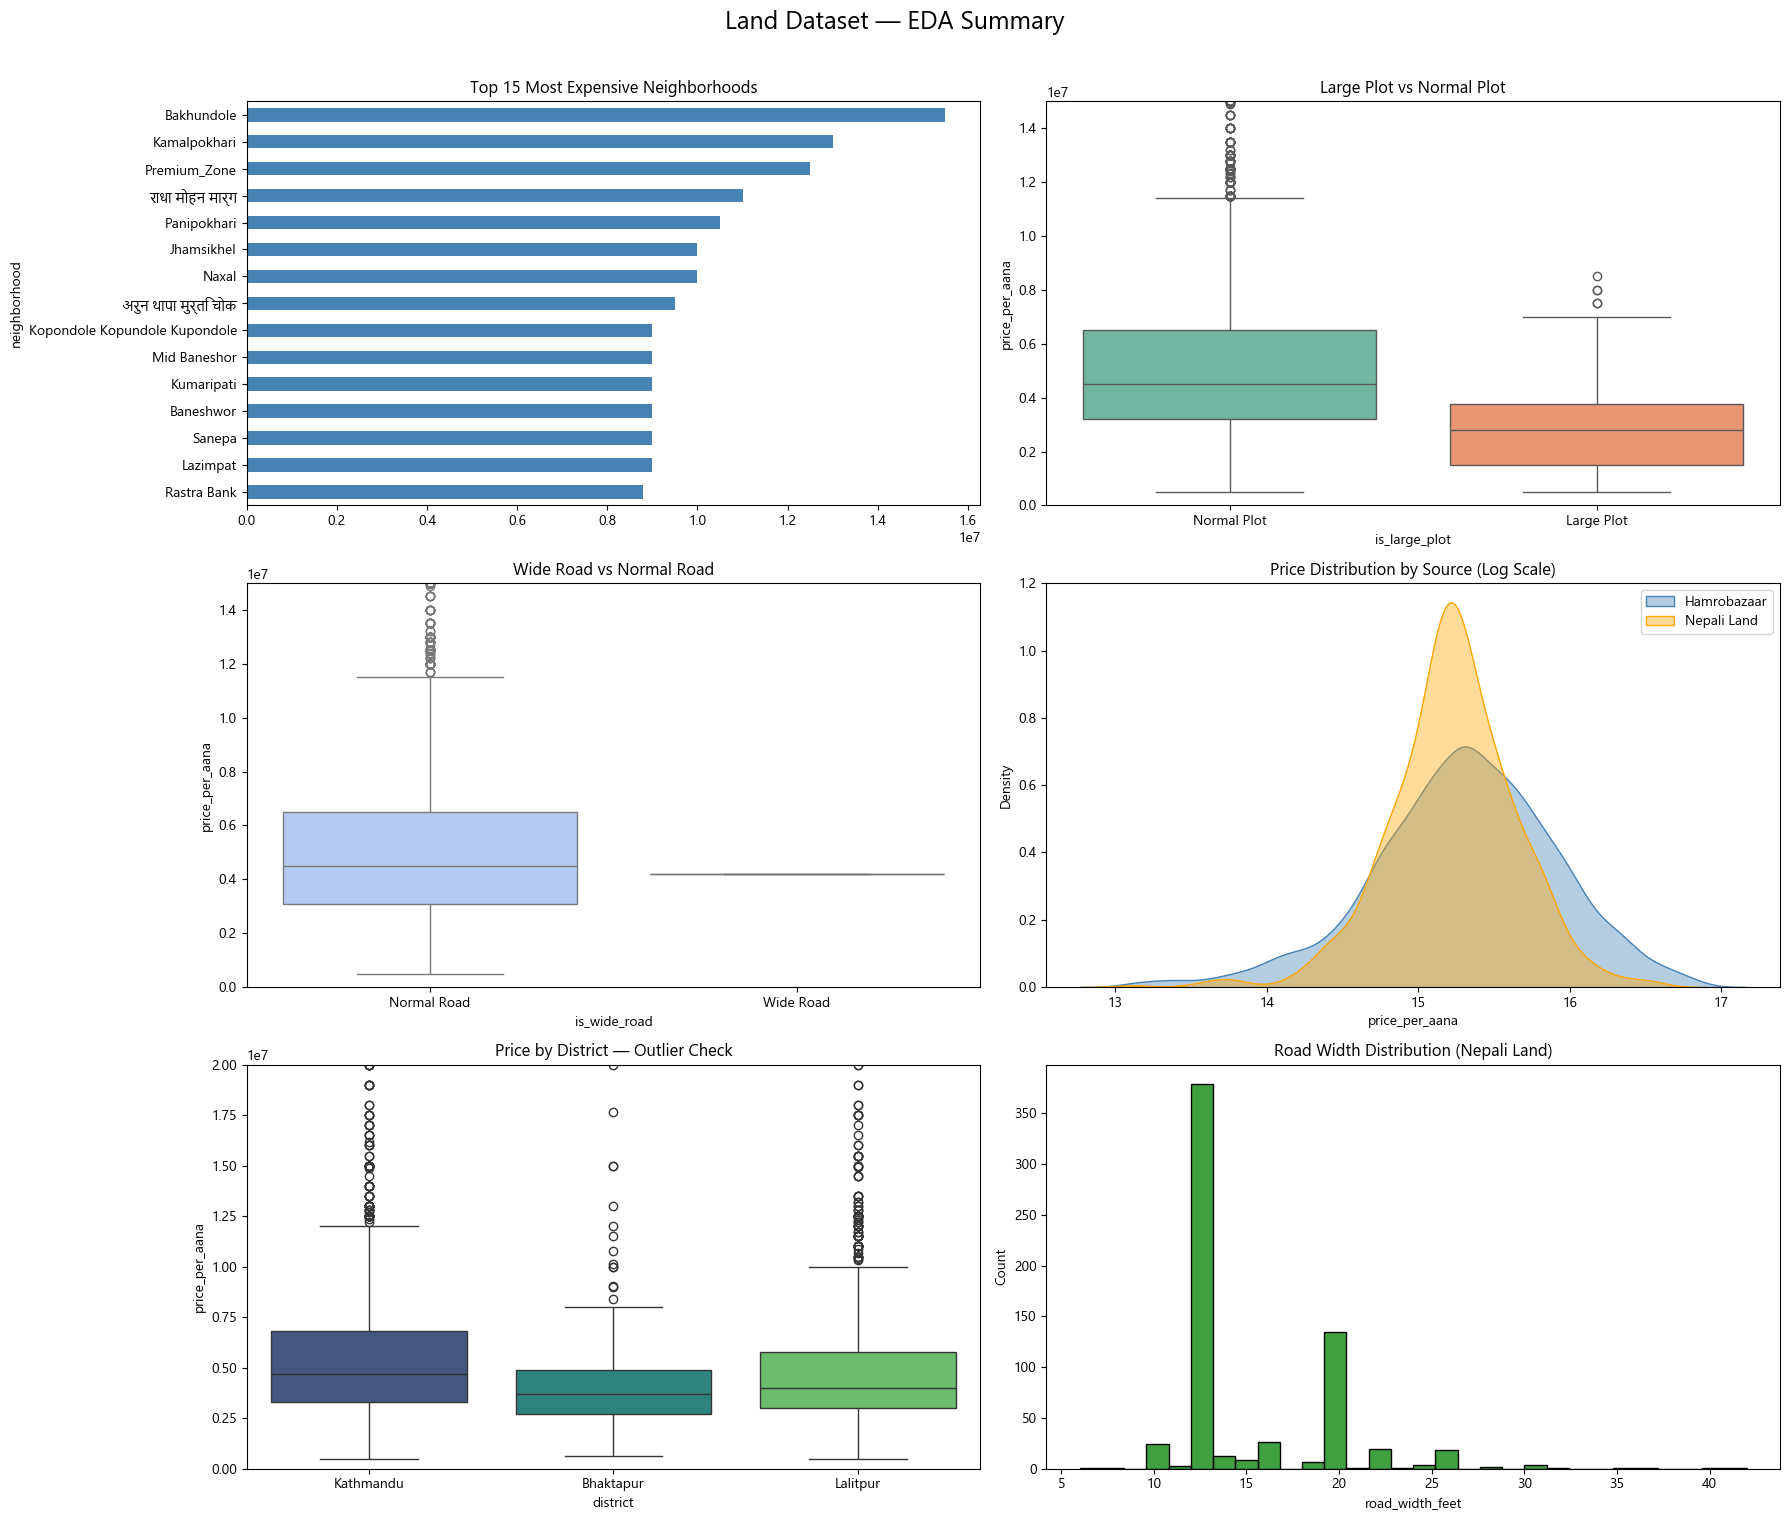

In [35]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SILENCE THE NOISE: This stops those pink warning boxes from appearing
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Land Dataset — EDA Summary', fontsize=18, fontweight='bold', y=1.01)

# ── Plot 1 — Top 15 neighborhoods ──
top_n = df_land.groupby('neighborhood')['price_per_aana']\
    .median().sort_values(ascending=False).head(15)
top_n.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 15 Most Expensive Neighborhoods', fontweight='bold')
axes[0,0].invert_yaxis()

# ── Plot 2 — added hue=x to fix FutureWarning ──
sns.boxplot(data=df_land, x='is_large_plot', y='price_per_aana',
            hue='is_large_plot', palette='Set2', legend=False, ax=axes[0,1])
axes[0,1].set_title('Large Plot vs Normal Plot', fontweight='bold')
axes[0,1].set_ylim(0, 15000000)
axes[0,1].set_xticklabels(['Normal Plot', 'Large Plot'])

# ── Plot 3 — added hue=x to fix FutureWarning ──
sns.boxplot(data=df_land, x='is_wide_road', y='price_per_aana',
            hue='is_wide_road', palette='coolwarm', legend=False, ax=axes[1,0])
axes[1,0].set_title('Wide Road vs Normal Road', fontweight='bold')
axes[1,0].set_ylim(0, 15000000)
axes[1,0].set_xticklabels(['Normal Road', 'Wide Road'])

# ── Plot 4 — Source price distribution overlay ──
hb_log = np.log1p(df_land[df_land['source']=='hamrobazaar']['price_per_aana'])
nl_log = np.log1p(df_land[df_land['source']=='nepali_land']['price_per_aana'])
sns.kdeplot(hb_log, ax=axes[1,1], label='Hamrobazaar', fill=True, alpha=0.4, color='steelblue')
sns.kdeplot(nl_log, ax=axes[1,1], label='Nepali Land', fill=True, alpha=0.4, color='orange')
axes[1,1].set_title('Price Distribution by Source (Log Scale)', fontweight='bold')
axes[1,1].legend()

# ── Plot 5 — added hue=x to fix FutureWarning ──
sns.boxplot(data=df_land, x='district', y='price_per_aana',
            hue='district', palette='viridis', legend=False, ax=axes[2,0])
axes[2,0].set_title('Price by District — Outlier Check', fontweight='bold')
axes[2,0].set_ylim(0, 20000000)

# ── Plot 6 — Road width distribution ──
df2_rows = df_land[df_land['source'] == 'nepali_land']
sns.histplot(df2_rows['road_width_feet'], bins=30, ax=axes[2,1], color='green')
axes[2,1].set_title('Road Width Distribution (Nepali Land)', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Fix 1 — Font for Nepali script in plots
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'Nirmala UI'  # Windows Nepali font
# If that doesn't work try:
# plt.rcParams['font.family'] = 'Arial Unicode MS'

# Fix 2 — Transliterate or flag road-name neighborhoods
# These keywords suggest road/street names not neighborhoods
road_keywords = ['Marg', 'Tol', 'Sadak', 'Road', 'Chowk', 'Path']

def is_road_name(name):
    return any(keyword.lower() in str(name).lower() for keyword in road_keywords)

# Check how many would be affected
road_names = df_land[df_land['neighborhood'].apply(is_road_name)]['neighborhood'].unique()
print(f"Road-like neighborhood names: {len(road_names)}")
print(road_names[:20])

Road-like neighborhood names: 9
['Airawa Tol' 'Bishal Nagar Marg' 'Golphutar Main Sadak'
 'Tribhuvan Rajpath' 'Jawalakhel Yekantakuna Sadak' 'Narayan Tole'
 'Talim Kendra Marg' 'Shrijanshil Tol' 'Suruchi Tol']


In [33]:
# Get median price for each road-like neighborhood
road_name_list = ['Airawa Tol', 'Bishal Nagar Marg', 'Golphutar Main Sadak',
                  'Tribhuvan Rajpath', 'Jawalakhel Yekantakuna Sadak', 'Narayan Tole',
                  'Talim Kendra Marg', 'Shrijanshil Tol', 'Suruchi Tol']

# Check their median prices first
print("=== Road-like neighborhood prices ===")
for name in road_name_list:
    median = df_land[df_land['neighborhood'] == name]['price_per_aana'].median()
    count  = df_land[df_land['neighborhood'] == name].shape[0]
    print(f"{name}: {median:,.0f} NPR ({count} rows)")

=== Road-like neighborhood prices ===
Airawa Tol: 4,000,000 NPR (3 rows)
Bishal Nagar Marg: 9,500,000 NPR (3 rows)
Golphutar Main Sadak: 4,350,000 NPR (3 rows)
Tribhuvan Rajpath: 4,550,000 NPR (4 rows)
Jawalakhel Yekantakuna Sadak: 8,100,000 NPR (4 rows)
Narayan Tole: 8,500,000 NPR (7 rows)
Talim Kendra Marg: 4,900,000 NPR (4 rows)
Shrijanshil Tol: 5,300,000 NPR (3 rows)
Suruchi Tol: 9,500,000 NPR (3 rows)


In [34]:
# Reassign road-like names to price zones
def price_to_zone(price):
    if price >= 10000000:
        return 'Premium_Zone'
    elif price >= 6000000:
        return 'High_Zone'
    elif price >= 4000000:
        return 'Mid_Zone'
    elif price >= 2000000:
        return 'Budget_Zone'
    else:
        return 'Outskirt_Zone'

road_name_mapping = {}
for name in road_name_list:
    median = df_land[df_land['neighborhood'] == name]['price_per_aana'].median()
    road_name_mapping[name] = price_to_zone(median)

print("=== Road name → Zone mapping ===")
for name, zone in road_name_mapping.items():
    print(f"{name} → {zone}")

# Apply to df_land
df_land['neighborhood'] = df_land['neighborhood'].replace(road_name_mapping)

print("\n=== Verification ===")
print(f"Any road names remaining: {df_land['neighborhood'].isin(road_name_list).sum()}")
print(f"Total unique neighborhoods: {df_land['neighborhood'].nunique()}")

=== Road name → Zone mapping ===
Airawa Tol → Mid_Zone
Bishal Nagar Marg → High_Zone
Golphutar Main Sadak → Mid_Zone
Tribhuvan Rajpath → Mid_Zone
Jawalakhel Yekantakuna Sadak → High_Zone
Narayan Tole → High_Zone
Talim Kendra Marg → Mid_Zone
Shrijanshil Tol → Mid_Zone
Suruchi Tol → High_Zone

=== Verification ===
Any road names remaining: 0
Total unique neighborhoods: 238


In [36]:
temp_df['neighborhood'].value_counts()

neighborhood
Budhanilkantha       455
Budget_Zone          256
High_Zone            254
Mid_Zone             199
Bhaisepati           109
                    ... 
Araniko Highway        3
Jitpurphedi            3
Hepali Height          3
Nil Barahi Mandir      3
Lazimpat               3
Name: count, Length: 247, dtype: int64

In [37]:
temp_df.sample()

,category,location_raw,district,neighborhood,road_type,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot,road_width_feet,is_wide_road,facing,source
2018,land,"Sanepa, Lalitpur",Lalitpur,Sanepa,Unknown,24.0,8000000.0,192000000.0,False,False,False,False,13.0,False,Unknown,hamrobazaar


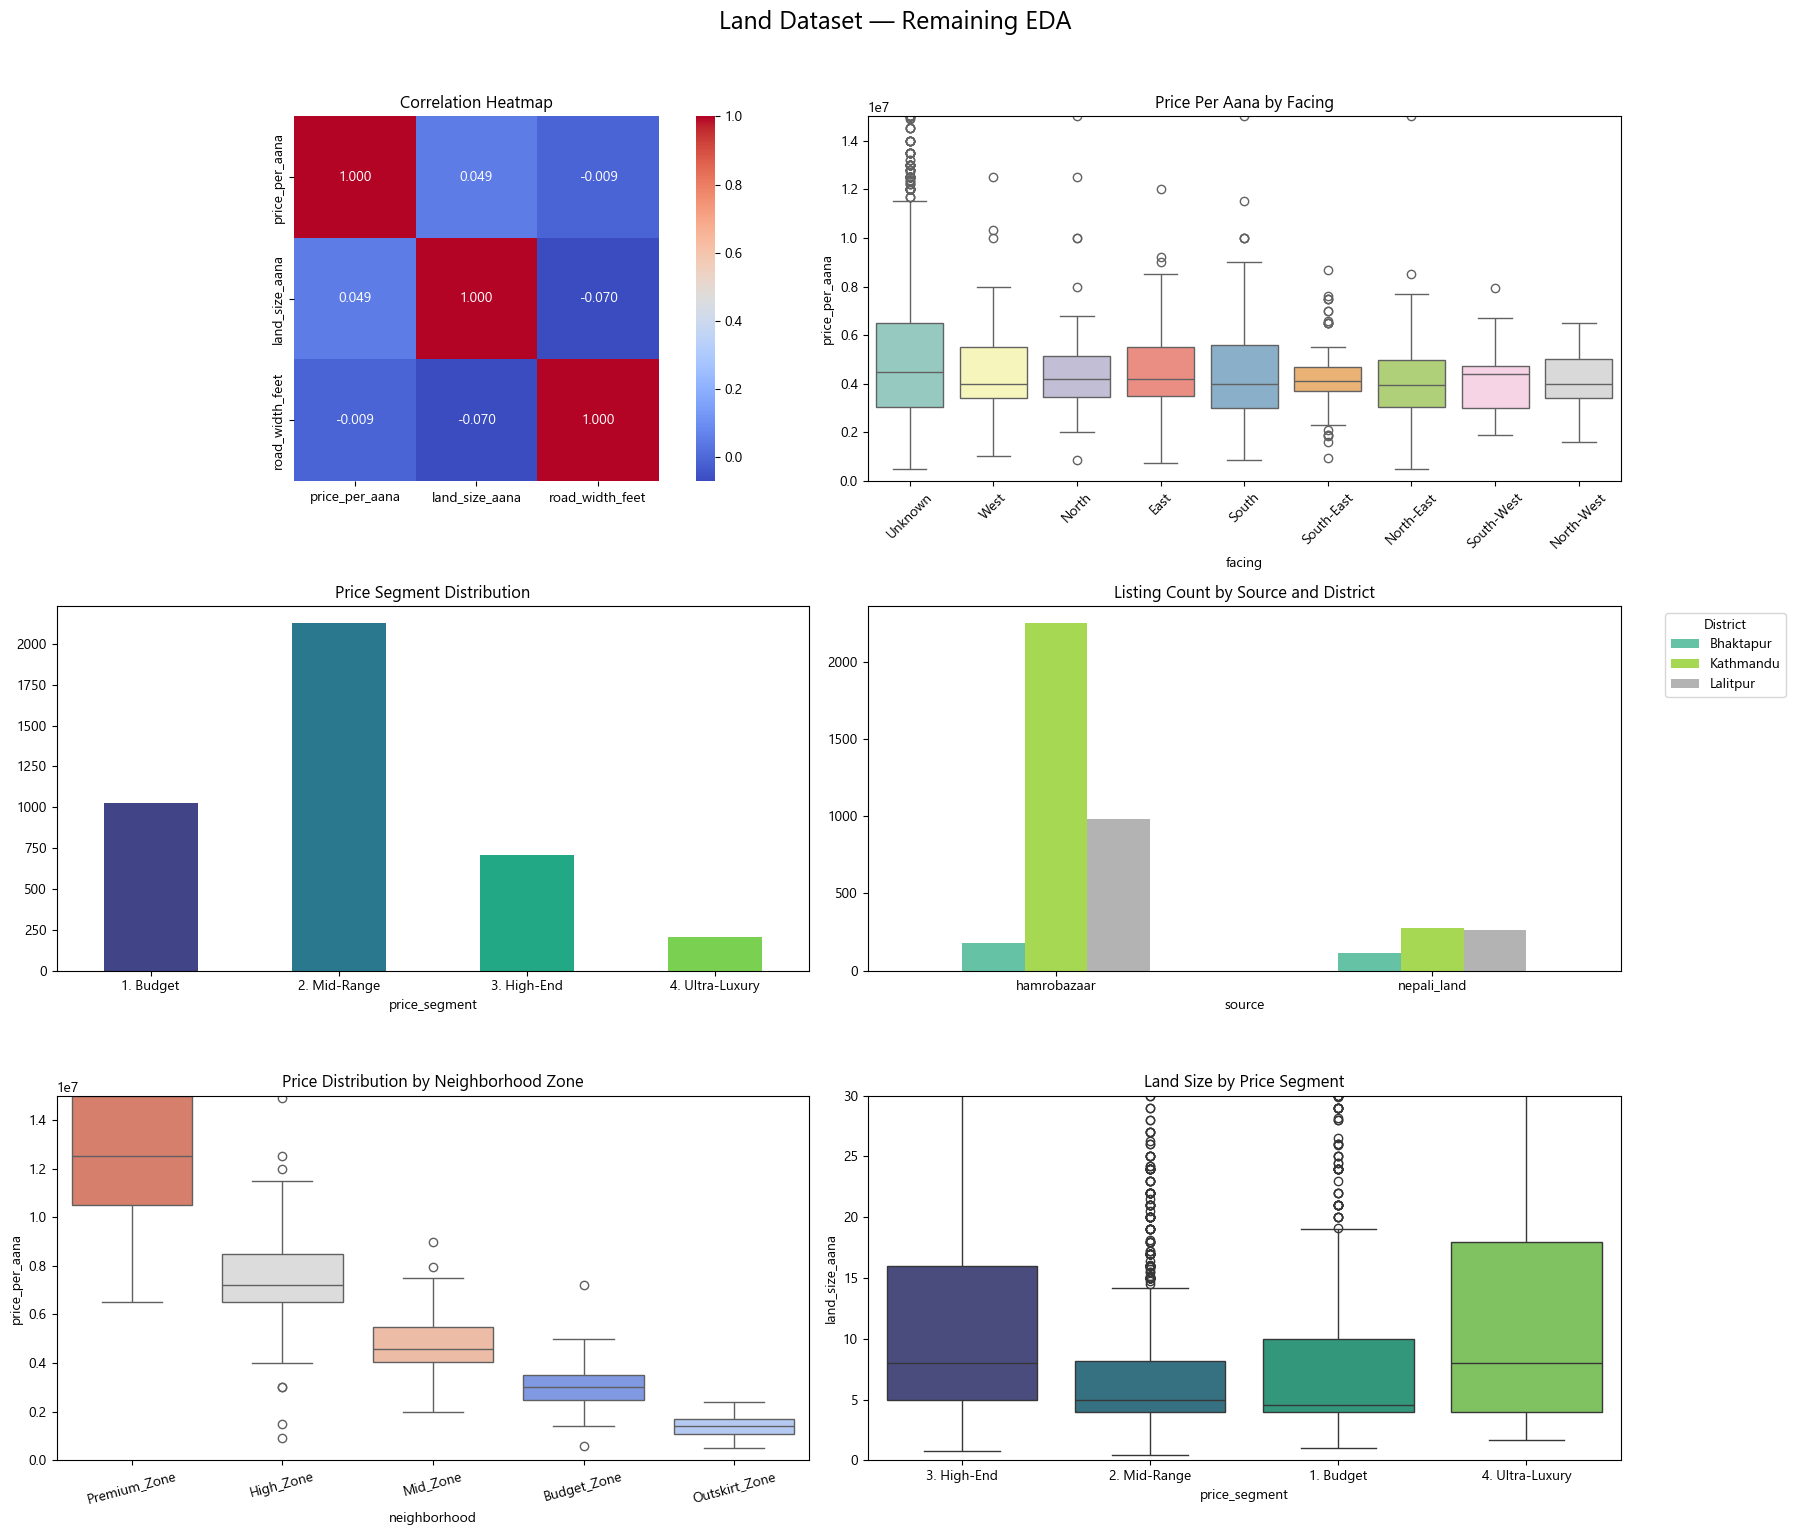

In [38]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SILENCE THE NOISE: Mutes pink warning boxes and font/glyph errors
warnings.filterwarnings('ignore')

# 2. Adjusted figsize height from 20 to 15 for better screen fit
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Land Dataset — Remaining EDA', fontsize=18, fontweight='bold', y=1.02)

# ── Plot 1 — Correlation heatmap ──
num_cols = ['price_per_aana', 'land_size_aana', 'road_width_feet']
corr = df_land[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0,0], square=True)
axes[0,0].set_title('Correlation Heatmap', fontweight='bold')

# ── Plot 2 — Facing vs price (Fixed Palette/Hue) ──
facing_counts = df_land['facing'].value_counts()
valid_facings  = facing_counts[facing_counts >= 10].index
df_facing      = df_land[df_land['facing'].isin(valid_facings)]
sns.boxplot(data=df_facing, x='facing', y='price_per_aana', 
            hue='facing', palette='Set3', legend=False, ax=axes[0,1])
axes[0,1].set_title('Price Per Aana by Facing', fontweight='bold')
axes[0,1].set_ylim(0, 15000000)
axes[0,1].tick_params(axis='x', rotation=45)

# ── Plot 3 — Price segments ──
q1, q3, q95 = df_land['price_per_aana'].quantile([0.25, 0.75, 0.95])
def get_segment(p):
    if p <= q1:   return '1. Budget'
    elif p <= q3: return '2. Mid-Range'
    elif p <= q95:return '3. High-End'
    else:         return '4. Ultra-Luxury'

df_land['price_segment'] = df_land['price_per_aana'].apply(get_segment)
# Using 'viridis' via color parameter for bar plots
df_land['price_segment'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,0], color=sns.color_palette('viridis', 4))
axes[1,0].set_title('Price Segment Distribution', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

# ── Plot 4 — Source deep dive ──
df_land.groupby(['source', 'district']).size().unstack().plot(
    kind='bar', ax=axes[1,1], colormap='Set2')
axes[1,1].set_title('Listing Count by Source and District', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')

# ── Plot 5 — Zone price comparison (Fixed Palette/Hue) ──
zones = ['Premium_Zone', 'High_Zone', 'Mid_Zone', 'Budget_Zone', 'Outskirt_Zone']
df_zones = df_land[df_land['neighborhood'].isin(zones)]
sns.boxplot(data=df_zones, x='neighborhood', y='price_per_aana', order=zones, 
            hue='neighborhood', palette='coolwarm', legend=False, ax=axes[2,0])
axes[2,0].set_title('Price Distribution by Neighborhood Zone', fontweight='bold')
axes[2,0].set_ylim(0, 15000000)
axes[2,0].tick_params(axis='x', rotation=15)

# ── Plot 6 — Land size by price segment (Fixed Palette/Hue) ──
sns.boxplot(data=df_land, x='price_segment', y='land_size_aana', 
            hue='price_segment', palette='viridis', legend=False, ax=axes[2,1])
axes[2,1].set_title('Land Size by Price Segment', fontweight='bold')
axes[2,1].set_ylim(0, 30)

plt.tight_layout()
plt.show()



In [39]:
# ─────────────────────────────────────────
# KEY STATS
# ─────────────────────────────────────────
print("=== Price Segment Boundaries ===")
print(f"Budget:       Below {q1:,.0f} NPR")
print(f"Mid-Range:    {q1:,.0f} to {q3:,.0f} NPR")
print(f"High-End:     {q3:,.0f} to {q95:,.0f} NPR")
print(f"Ultra-Luxury: Above {q95:,.0f} NPR")

print("\n=== Facing vs Price ===")
print(df_facing.groupby('facing')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Source vs Road Type ===")
print(df_land.groupby(['source','road_type']).size().unstack(fill_value=0))

print("\n=== Zone vs Price ===")
print(df_land.groupby('neighborhood')['price_per_aana']\
      .median().sort_values(ascending=False).head(10))

print("\n=== Land Size by Segment ===")
print(df_land.groupby('price_segment')['land_size_aana'].median())

=== Price Segment Boundaries ===
Budget:       Below 3,100,000 NPR
Mid-Range:    3,100,000 to 6,500,000 NPR
High-End:     6,500,000 to 11,190,000 NPR
Ultra-Luxury: Above 11,190,000 NPR

=== Facing vs Price ===
facing
Unknown       4500000.0
South-West    4400000.0
East          4200000.0
North         4200000.0
South-East    4100000.0
North-West    4000000.0
South         4000000.0
West          4000000.0
North-East    3950000.0
Name: price_per_aana, dtype: float64

=== Source vs Road Type ===
road_type    Gravel  Medium Road  Narrow Road  Paved  Pitched  Unknown  \
source                                                                   
hamrobazaar     306          750           99      0      767      703   
nepali_land     246            0            0    218      168       20   

road_type    Wide Road  
source                  
hamrobazaar        786  
nepali_land          0  

=== Zone vs Price ===
neighborhood
Bakhundole                       15500000.0
Kamalpokhari            

In [40]:
# Remap to a unified road quality scale
road_quality_map = {
    'Wide Road':    'High Access',
    'Pitched':      'High Access',
    'Paved':        'High Access',
    'Medium Road':  'Mid Access',
    'Narrow Road':  'Low Access',
    'Gravel':       'Low Access',
    'Unknown':      'Unknown'
}
df_land['road_type'] = df_land['road_type'].replace(road_quality_map)

print("=== Unified road type distribution ===")
print(df_land['road_type'].value_counts())

print("\n=== Road type by source after unification ===")
print(df_land.groupby(['source','road_type']).size().unstack(fill_value=0))

=== Unified road type distribution ===
road_type
High Access    1939
Mid Access      750
Unknown         723
Low Access      651
Name: count, dtype: int64

=== Road type by source after unification ===
road_type    High Access  Low Access  Mid Access  Unknown
source                                                   
hamrobazaar         1553         405         750      703
nepali_land          386         246           0       20


In [41]:
print(f"Shape: {df_land.shape}")
print(f"Columns: {list(df_land.columns)}")
print(f"Nulls: {df_land.isnull().sum().sum()}")
print(f"Unique neighborhoods: {df_land['neighborhood'].nunique()}")
print(f"Road types: {df_land['road_type'].value_counts().to_dict()}")

Shape: (4063, 17)
Columns: ['category', 'location_raw', 'district', 'neighborhood', 'road_type', 'land_size_aana', 'price_per_aana', 'calculated_total_price', 'is_price_suspect', 'is_price_outlier', 'is_rate_outlier', 'is_large_plot', 'road_width_feet', 'is_wide_road', 'facing', 'source', 'price_segment']
Nulls: 0
Unique neighborhoods: 238
Road types: {'High Access': 1939, 'Mid Access': 750, 'Unknown': 723, 'Low Access': 651}


In [42]:
# Save df_land (cleaned, EDA-ready version)
df_land.to_csv('cleaned_land_merged_final_after_eda.csv', index=False)
print(f"✅ df_land saved — Shape: {df_land.shape}")

✅ df_land saved — Shape: (4063, 17)
